# Model for predicting the fiber volume content of composites from SEM images
## Demonstration of the model

**Paper**: F. Rothenhaeusler, R. Q. Albuquerque, M. Sticher, C. Kuenneth, and H. Ruckdaeschel. “Application of convolutional neural networks and ensemble methods in the fiber volume content analysis of natural fiber composites”. Machine Learning with Applications 19 (2025), 100609. Web: https://doi.org/10.1016/j.mlwa.2024.100609

In the code below:
- The pre-trained models are loaded and predictions are performed on both the training and test sets, from where parity plots are shown in each case.
- An ensemble prediction is performed for a new SEM image named "new_image.tif"
<Br>

80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 234ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


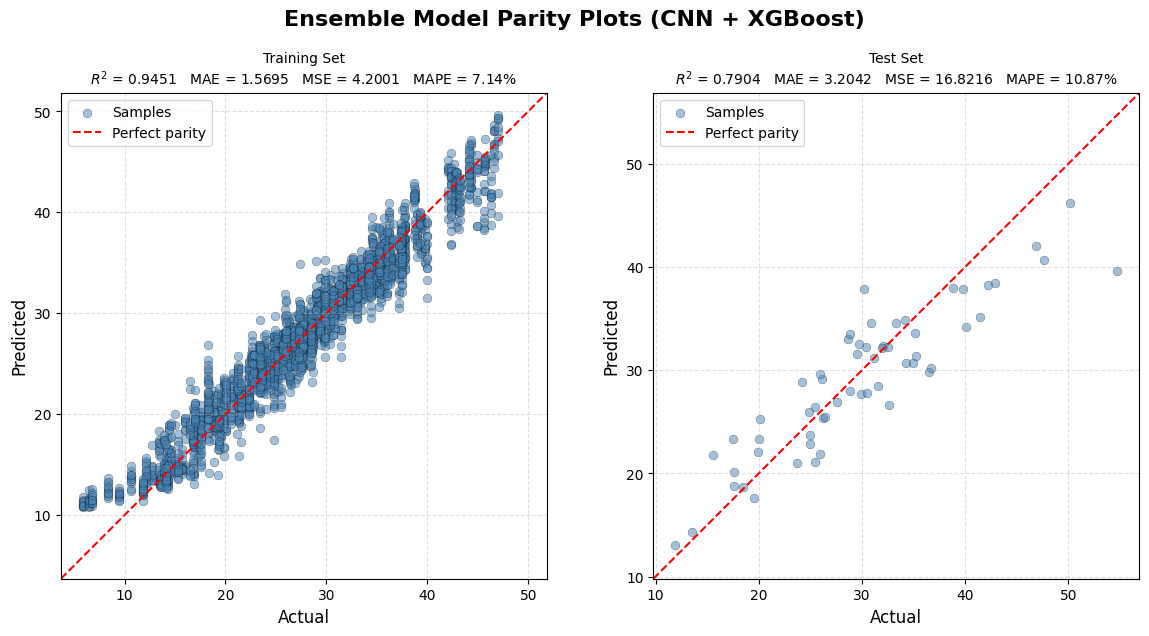

In [51]:
# import required libraries
import numpy as np
import matplotlib.pyplot as plt
import keras 
import joblib
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import r2_score as R2

# Rebuid CNN, import trained weights (workaround due to keras compatibility issues)
model_cnn = keras.Sequential([
    keras.layers.Input(shape=(192, 256, 1)),
    keras.layers.Conv2D(97, (5,5), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.BatchNormalization(momentum=0.99, epsilon=0.001),
    keras.layers.Conv2D(89, (4,4), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.BatchNormalization(momentum=0.99, epsilon=0.001),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.BatchNormalization(momentum=0.99, epsilon=0.001),
    keras.layers.Conv2D(117, (2,2), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.BatchNormalization(momentum=0.99, epsilon=0.001),
    keras.layers.Conv2D(77, (2,2), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.BatchNormalization(momentum=0.99, epsilon=0.001),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.2896677),
    keras.layers.Dense(87, activation='relu'),
    keras.layers.Dense(6, activation='relu'),
    keras.layers.Dense(34, activation='relu'),
    keras.layers.Dense(1, activation='linear'),
])
model_cnn.compile(optimizer='adam', loss='mse', metrics=['accuracy'])
model_cnn.build((None, 192, 256, 1))

##### load data #####
X_train = np.load('X_train_aug10.npy')
X_test = np.load('X_test.npy')
y_train = np.load('y_train_aug10.npy')
y_test = np.load('y_test.npy')

##### load pre-trained models (trained on the training set, which is 10x augmented, see main paper) #####
model_cnn.load_weights('cnn.keras')
model_info_xgb = joblib.load('model_info_xgb.joblib')

##### configure model and scalers #####
model_scalers_cnn = joblib.load('model_scalers_cnn.joblib')
#scalerx_cnn = model_scalers_cnn['xscaler']
scalery_cnn = model_scalers_cnn['yscaler']

model_xgb = model_info_xgb['model']
#scalerx_xgb = model_info_xgb['xscaler']
scalery_xgb = model_info_xgb['yscaler']


##### predictions on the training set #####

# for CNN
predictions_training_cnn_scaled = model_cnn.predict(X_train)
predictions_training_cnn = scalery_cnn.inverse_transform(predictions_training_cnn_scaled)

# for xgboost
X_train_pp = X_train.reshape(X_train.shape[0], -1) # n_images x (width x height)
predictions_training_xgb_scaled = model_xgb.predict(X_train_pp[:,::5]) # each 5th pixel only
predictions_training_xgb = scalery_xgb.inverse_transform(predictions_training_xgb_scaled.reshape(-1,1))

# ensemble prediction (equation 9 of the main paper)
predictions_ensemble_train = 0.671 * predictions_training_cnn + 0.362 * predictions_training_xgb

# metrics
r2_training = R2(y_train, predictions_ensemble_train)
mae_training = MAE(y_train, predictions_ensemble_train)
mse_training = MSE(y_train, predictions_ensemble_train)
mape_training = MAPE(y_train, predictions_ensemble_train) * 100


##### predictions on the test set #####

# for CNN
predictions_test_cnn_scaled = model_cnn.predict(X_test)
predictions_test_cnn = scalery_cnn.inverse_transform(predictions_test_cnn_scaled)

# for xgboost
X_test_pp = X_test.reshape(X_test.shape[0], -1) # n_images x (width x height)
predictions_test_xgb_scaled = model_xgb.predict(X_test_pp[:,::5]) # each 5th pixel only
predictions_test_xgb = scalery_xgb.inverse_transform(predictions_test_xgb_scaled.reshape(-1,1))

# ensemble prediction (equation 9 of the main paper)
predictions_ensemble_test = 0.671 * predictions_test_cnn + 0.362 * predictions_test_xgb

# metrics 
r2_test =   R2(y_test, predictions_ensemble_test)
mae_test =  MAE(y_test, predictions_ensemble_test)
mse_test =  MSE(y_test, predictions_ensemble_test)
mape_test = MAPE(y_test, predictions_ensemble_test) * 100


##### Check parity plots for training and test sets #####
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, y_true, y_pred, metrics, title in zip(
    axes,
    [y_train, y_test],
    [predictions_ensemble_train, predictions_ensemble_test],
    [(r2_training, mae_training, mse_training, mape_training),
     (r2_test,     mae_test,     mse_test,     mape_test)],
    ['Training Set', 'Test Set']
):
    y_true_flat = np.array(y_true).flatten()
    y_pred_flat = np.array(y_pred).flatten()

    # scatter
    ax.scatter(y_true_flat, y_pred_flat, alpha=0.5, edgecolors='k',
               linewidths=0.3, s=40, color='steelblue', label='Samples')

    # perfect parity line
    lim_min = min(y_true_flat.min(), y_pred_flat.min())
    lim_max = max(y_true_flat.max(), y_pred_flat.max())
    margin = (lim_max - lim_min) * 0.05
    ax.plot([lim_min - margin, lim_max + margin],
            [lim_min - margin, lim_max + margin],
            'r--', linewidth=1.5, label='Perfect parity')

    ax.set_xlim(lim_min - margin, lim_max + margin)
    ax.set_ylim(lim_min - margin, lim_max + margin)
    ax.set_aspect('equal')

    r2, mae, mse, mape = metrics
    ax.set_title(
        f'{title}\n'
        f'$R^2$ = {r2:.4f}   MAE = {mae:.4f}   MSE = {mse:.4f}   MAPE = {mape:.2f}%',
        fontsize=10
    )
    ax.set_xlabel('Actual', fontsize=12)
    ax.set_ylabel('Predicted', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Ensemble Model Parity Plots (CNN + XGBoost)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout();

<Br><Br>
# Predict the fiber volume content for a new SEM image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step



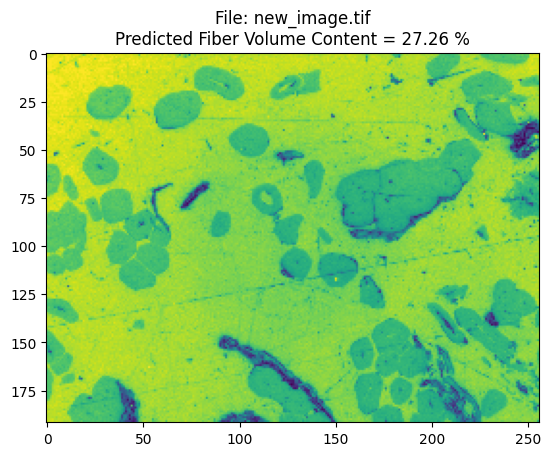

In [49]:
###################################
############# INPUT ###############
###################################


filename = "new_image.tif" # here is the name of your new image


###################################
## DO NOT CHANGE THE LINES BELOW ##
###################################
# load/process image
from PIL import Image # install pillow, if not yet done!
img = Image.open(filename) 
img = img.resize((256, 192)) # (width, height)
img_array_ = np.array(img) / 255 # normalize it
img_array = img_array_.reshape(-1,192,256)

# CNN predictions
pred_cnn_scaled = model_cnn.predict(img_array)
pred_cnn = scalery_cnn.inverse_transform(pred_cnn_scaled)

# xgboost predictions
X_new = img_array.reshape(img_array.shape[0], -1) # n_images x (width x height)
pred_xgb_scaled = model_xgb.predict(X_new[:,::5]) # each 5th pixel only
pred_xgb = scalery_xgb.inverse_transform(pred_xgb_scaled.reshape(-1,1))

# ensemble prediction
pred_ensemble = 0.671 * pred_cnn + 0.362 * pred_xgb
print()

# final result
plt.imshow(img_array_)
plt.title(f'File: {filename}\nPredicted Fiber Volume Content = {pred_ensemble[0,0]:.2f} %');